# Chapter 5: Adversarial Validation

**When train and test differ, does the domain AUC tell you whether the target model's score has changed?**

A high domain AUC invites a fix and a near-0.5 one invites relief. Measuring both beside the target score shows when each reaction is wrong, and what reweighting does when it is applied anyway.

*Constructed data; the sizes of these effects are properties of this generator. Weighting helped one state a little, did nothing in two and hurt in one; none of that is a competition result.*

## The experiment

Constructed binary task with 2,000 training rows and 2,000 test rows, three numeric features and a time-like field. The same training set is used in all four states; only the test population changes: nothing, x1 shifted right (covariate shift, label rule unchanged), the time field moved later (label rule unchanged), or the effect of x2 on the label reversed with x unchanged. A gradient-boosting domain classifier (HistGradientBoostingClassifier standing in for the chapter's LightGBM) gives out-of-fold AUC from all four input columns (three numeric features and the time-like field). The target model is a logistic regression on the three numeric features, scored by 5-fold cross-validation, on the test rows, and on the test rows again after training with the chapter's capped, mean-scaled density-ratio weights. Each number is a mean over 16 independent draws.

In [1]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

from kaggle_companion.activities._common import clean

SEED = 5
REPLICATES = 16      # independent train/test draws per shift type; every number is their mean
N = 2000             # training rows and test rows
CAP = 10.0           # the chapter's weight cap
SHIFTS = {0: "none", 1: "covariate", 2: "timestamp", 3: "sign_flip"}


def generate(shift, seed):
    """Train and test rows. Columns: x1, x2, x3 (noise), t (a time-like field). Test differs in one way only."""
    rng = np.random.default_rng(seed)

    def rows(n, test):
        x = rng.normal(size=(n, 3))
        t = rng.uniform(0, 1, n)
        beta2 = 0.8
        if test and shift == "covariate":
            x[:, 0] += 1.0                      # x1 moves right; P(y | x) is untouched
        if test and shift == "timestamp":
            t = t + 1.0                         # the test period is later; the label rule is untouched
        if test and shift == "sign_flip":
            beta2 = -0.8                        # same x, but x2 now pushes the label the other way
        logit = 1.2 * x[:, 0] + beta2 * x[:, 1] + 0.7 * (x[:, 0] ** 2 - 1)
        y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
        return np.column_stack([x, t]), y

    return rows(N, False), rows(N, True)


def domain_density_weights(q_oof, n_train, n_test, cap=CAP):
    """The chapter's weights: capped odds q/(1-q) with the sampling-prior correction, scaled to mean 1."""
    q = np.clip(np.asarray(q_oof, dtype=float), 1e-6, 1 - 1e-6)
    weights = np.minimum(q / (1 - q) * n_train / n_test, cap)
    return weights / weights.mean()


def domain_auc(features, domain, seed=0):
    """Out-of-fold AUC of a classifier that tries to tell the two populations apart."""
    oof = np.zeros(len(domain))
    for fit, out in StratifiedKFold(5, shuffle=True, random_state=seed).split(features, domain):
        model = HistGradientBoostingClassifier(max_iter=60, max_depth=3, random_state=0).fit(features[fit], domain[fit])
        oof[out] = model.predict_proba(features[out])[:, 1]
    return roc_auc_score(domain, oof), oof


def one_replicate(shift, seed):
    (x_tr, y_tr), (x_te, y_te) = generate(shift, seed)
    features = np.vstack([x_tr, x_te])
    domain = np.r_[np.zeros(N), np.ones(N)]
    auc, oof = domain_auc(features, domain)
    shuffled_auc, _ = domain_auc(features, np.random.default_rng(seed + 1).permutation(domain))
    w = domain_density_weights(oof[:N], N, N)               # weights for training rows from their out-of-fold q
    ess = w.sum() ** 2 / (w ** 2).sum() / N                 # effective sample size as a fraction of N

    cv = []                                                 # the target model: logistic regression on x1, x2, x3 (not t)
    for fit, out in StratifiedKFold(5, shuffle=True, random_state=1).split(x_tr, y_tr):
        m = LogisticRegression(max_iter=500).fit(x_tr[fit, :3], y_tr[fit])
        cv.append(roc_auc_score(y_tr[out], m.predict_proba(x_tr[out, :3])[:, 1]))
    plain = LogisticRegression(max_iter=500).fit(x_tr[:, :3], y_tr)
    weighted = LogisticRegression(max_iter=500).fit(x_tr[:, :3], y_tr, sample_weight=w)
    return {"domain_auc": auc, "shuffled_domain_auc": shuffled_auc, "cv_auc": np.mean(cv),
            "test_auc": roc_auc_score(y_te, plain.predict_proba(x_te[:, :3])[:, 1]),
            "weighted_test_auc": roc_auc_score(y_te, weighted.predict_proba(x_te[:, :3])[:, 1]),
            "weight_ess": ess}


def run(shift_type):
    shift = SHIFTS[int(shift_type)]
    reps = [one_replicate(shift, SEED * 1000 + i) for i in range(REPLICATES)]
    keys = list(reps[0])
    out = {k: float(np.mean([r[k] for r in reps])) for k in keys}
    out["per_replicate"] = {k: [r[k] for r in reps] for k in ("domain_auc", "test_auc", "weighted_test_auc")}
    out["weighting_gain"] = float(np.mean([r["weighted_test_auc"] - r["test_auc"] for r in reps]))
    return clean({"shift_type": int(shift_type), "shift": shift, **out,
                  "train_rows": N, "test_rows": N, "replicates": REPLICATES})


## Measure it across the control

The control is **how the test population differs from training**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch05 import explain

VALUES = [0, 1, 2, 3]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                             0      1      2      3
Domain AUC               0.499  0.749  1.000  0.499
Cross-validation AUC     0.771  0.771  0.771  0.771
Test AUC, unweighted     0.776  0.855  0.776  0.576
Test AUC, weighted       0.776  0.873  0.703  0.575
Weight effective sample  93.3%  41.1%   0.5%  93.3%


## Look at it

The figure shows the default setting, how the test population differs from training = 3.

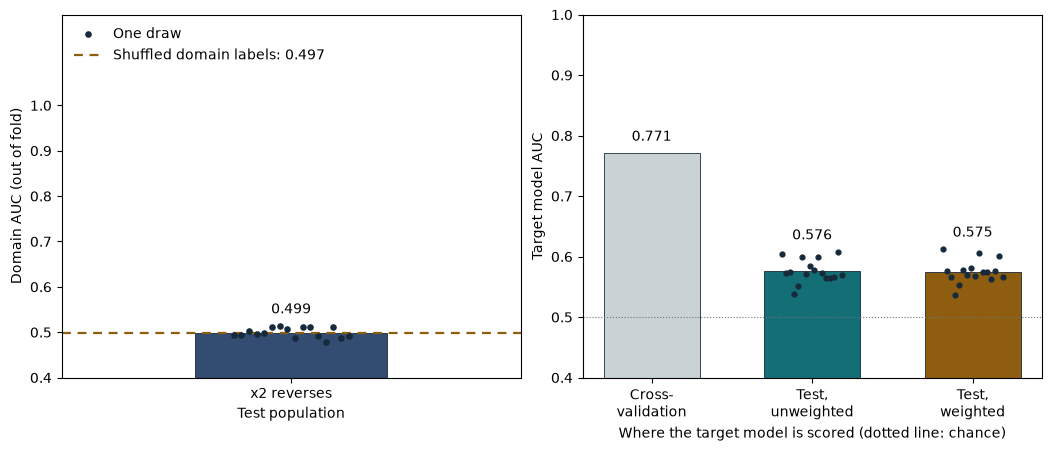

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch05 import draw, NCOLS, HEIGHT

DEFAULT = 3
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

Domain AUC is 0.499 (shuffled labels give 0.497). The target model scores 0.576 on test rows against 0.771 in cross-validation: 0.771 - 0.576 = 0.195 below cross-validation. The domain classifier sees nothing, yet the target model's score changed: the label rule moved, not the inputs. Weighting changes the test AUC by less than 0.01.

- Domain AUC: 0.499 against 0.497 with shuffled labels.
- Test minus cross-validation: 0.576 - 0.771 = -0.195.
- Weighting gain on test: 0.575 - 0.576 = -0.001.
- Effective sample size of the weights: 93.3% of the 2,000 training rows.

## Apply this to your competition

- Run the domain classifier, then name the separating feature and why it separates before touching anything.
- Compare the target model on a held-out set built to resemble the test (new subjects, later dates) before and after any change.
- When the separating field is a date or ID the test will always differ on, keep it out of the target model rather than reweighting on it.
- Check the effective sample size of any weights; if it is a tiny fraction of the rows, the weights are a symptom, not a fix.

Book location: Chapter 5, Interpreting the AUC.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)